In [1]:
#import csv
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from matplotlib.colors import ListedColormap




In [19]:
# read the data from csv file
#filename = "data/Interview_export.csv"
#filename = "data/Interview_export_2.csv"
#filename = "data/Interview_export_3.csv"
filename = "data/Interview_export_4.csv"
# import with , as decimal separator
df = pd.read_csv(filename, sep=';', encoding='latin1', decimal=',')
print(f"Loaded {len(df)} responses")
df.sort_index

Loaded 11 responses


<bound method DataFrame.sort_index of     Respondent Respondent-Role  Respondent-Company  \
0            1         Planner                   4   
1            2        Operator                   4   
2            3        Operator                   4   
3            4         Planner                   3   
4            5         Planner                   1   
5            6        Operator                   3   
6            7        Operator                   5   
7            8         Planner                   5   
8            9         Planner                   5   
9           10         Planner                   2   
10          11         Planner                   2   

    Respondent-Years in current role  \
0                                2.5   
1                               18.0   
2                                3.0   
3                                2.0   
4                                2.0   
5                               11.0   
6                                

In [20]:
for c in df.columns:
    print(c)

Respondent
Respondent-Role
Respondent-Company
Respondent-Years in current role
Respondent-Years of relevant exp in total
Respondent-Education level
Respondent-University
Focus-Capacity assessment
Focus-Constraints 
Focus-Uncertainty handeling
Focus-Probabalistic analysis
Focus-Load and generation analysis
Focus-Operational control
Focus-Risk analysis
Focus-Simulation
Focus-Optimization
Focus-ML techniques
Focus-Business oriented
Focus-Operation planning
Focus-Market operation
Methods-artificial bee colony
Methods-automatic generation control agc
Methods-contingency analysis
Methods-cost-benefit analysis
Methods-deep learning
Methods-demand response
Methods-demand side management dsm
Methods-dynamic line rating
Methods-economic dispatch
Methods-energy demand forecasting
Methods-energy market forecasting
Methods-energy production forecasting
Methods-energy resilience analysis
Methods-ensemble learning
Methods-expected energy not served
Methods-failure modeling
Methods-fault analysis
Meth

## Conversation focus

In [101]:

# Sort the entire dataframe by company number
df_sorted = df.sort_values('Respondent-Company')

# Select columns that start with "Focus"
focus_cols = [col for col in df_sorted.columns if col.startswith("Focus")]
focus_col_names = [col.replace("Focus-","").strip() for col in focus_cols]

# Sort columns 
custom_order = ['Capacity assessment', 'Load and generation analysis','Constraints','Simulation','Operational control', 'Operation planning', 'Market operation', 'Business oriented', 'Risk analysis',  'Optimization','Uncertainty handeling', 'Probabalistic analysis', 'ML techniques']
sorted_indices = [focus_col_names.index(topic) for topic in custom_order if topic in focus_col_names]
focus_cols_sorted = [focus_cols[i] for i in sorted_indices]
focus_col_names_sorted = [focus_col_names[i] for i in sorted_indices]

# Define custom colors for each score level
colors1 = ['#f7f7f7', '#abd9e9', '#74a9cf', '#2b8cbe']  # Light blue to dark blue
#alternative with more contrast and more colors for better resolution
colors2 = ['#ffffcc', '#ffeda0', '#fed976', '#feb24c', '#fd8d3c', '#fc4e2a', '#e31a1c', '#bd0026', '#800026']
custom_cmap = ListedColormap(colors2)


In [102]:
# Normalize focus scores
focus_scores = df_sorted[focus_cols_sorted]
focus_scores_normalized = focus_scores.div(focus_scores.sum(axis=1), axis=0)

df_normalized = df_sorted.copy()
df_normalized[focus_cols_sorted] = focus_scores_normalized
print("Normalized focus scores added to df_normalized")


Normalized focus scores added to df_normalized


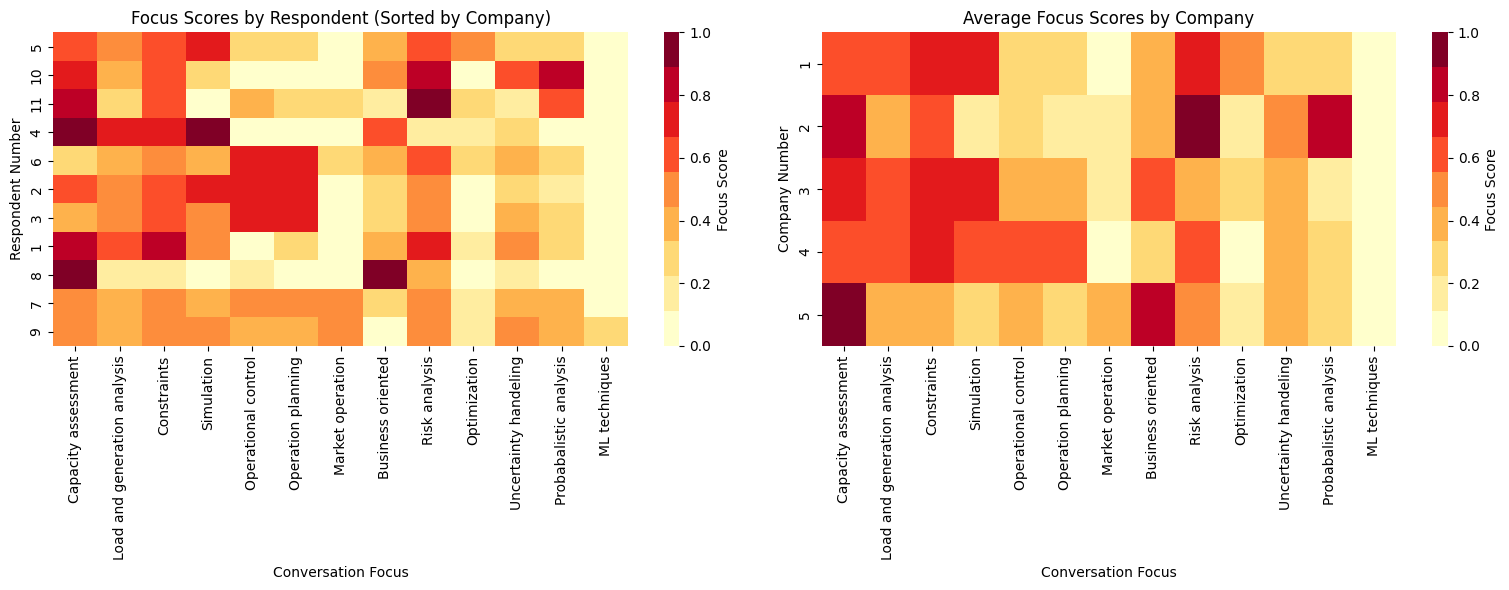

In [ ]:
# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(len(focus_cols_sorted)*1.2,6))  # Correct order: fig, axes

# Left plot: Individual respondents sorted by company
scores_respondents = df_normalized[focus_cols_sorted].values / focus_scores_normalized.max().max() * 2
sns.heatmap(scores_respondents,
           yticklabels=df_normalized['Respondent'], 
           xticklabels=focus_col_names_sorted,
           cmap=custom_cmap,
           vmin=0, vmax=scores_respondents.max().max()/2,
           annot=False,
           fmt='.2f',
           cbar_kws={'label': 'Focus Score'},
           ax=axes[0])  # Use axes[0], not fig[0]
axes[0].set_xlabel("Conversation Focus")
axes[0].set_ylabel("Respondent Number")
axes[0].set_title("Focus Scores by Respondent (Sorted by Company)")

# Right plot: Company averages
company_grouped = df_normalized.groupby('Respondent-Company')[focus_cols_sorted].mean()
scores_company = company_grouped / company_grouped.max().max()
sns.heatmap(scores_company, 
           xticklabels=focus_col_names_sorted,
           cmap=custom_cmap,
           vmin=0, vmax=scores_company.max().max(),
           annot=False,
           fmt='.2f',
           cbar_kws={'label': 'Focus Score'},
           ax=axes[1])  # Use axes[1], not fig[1]
axes[1].set_xlabel("Conversation Focus")
axes[1].set_ylabel("Company Number")
axes[1].set_title("Average Focus Scores by Company")
plt.tight_layout()
plt.savefig("plots/focus_scores_comparison.pdf")
plt.show()

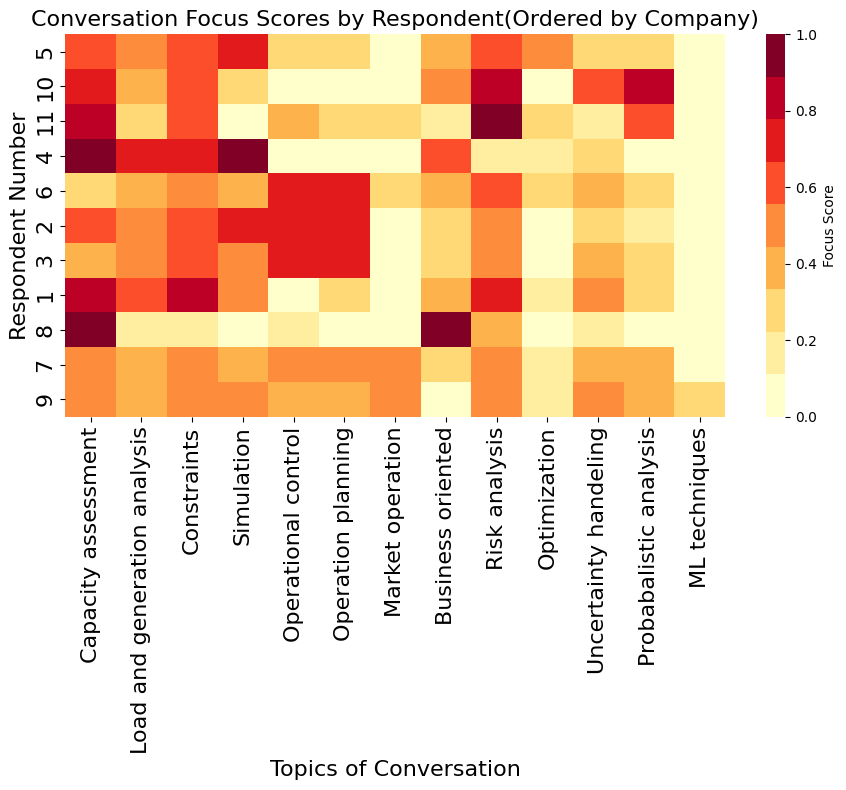

In [146]:
scores_respondents = df_normalized[focus_cols_sorted].values / focus_scores_normalized.max().max() * 2
fontsize=16
plt.figure(figsize=(len(focus_cols_sorted)*0.7, 8))
sns.heatmap(scores_respondents,
           yticklabels=df_normalized['Respondent'], 
           xticklabels=focus_col_names_sorted,
           cmap=custom_cmap,
           vmin=0, vmax=scores_respondents.max().max()/2,
           annot=False,
           fmt='.2f',
           cbar_kws={'label': 'Focus Score'},
           )
plt.xlabel("Topics of Conversation",fontsize=fontsize)
plt.ylabel("Respondent Number",fontsize=fontsize)
plt.title("Conversation Focus Scores by Respondent(Ordered by Company)",fontsize=fontsize)    
plt.tick_params(axis='both', which='major', labelsize=fontsize)
plt.tight_layout()
plt.savefig("plots/focus_scores_respondents.pdf")
plt.show()

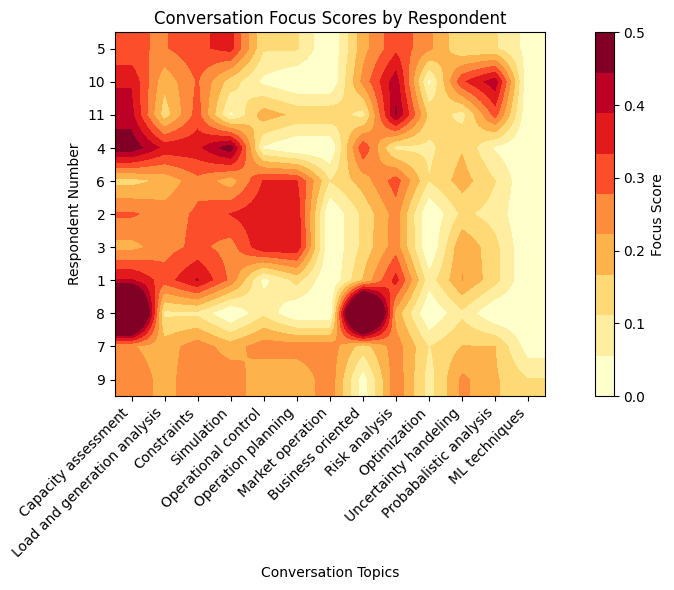

In [120]:
# Create figure
scores = df_normalized[focus_cols_sorted].values/focus_scores_normalized.max().max()
plt.figure(figsize=(len(focus_cols_sorted)*0.8, 6))
im = plt.imshow(scores,#df_normalized[focus_cols_sorted], 
               cmap=custom_cmap, 
               aspect='equal',# options
               interpolation='bilinear',  # Options: 'bilinear', 'bicubic', 'gaussian', 'lanczos'
               vmin=0, vmax=scores.max().max()/2
               )

plt.colorbar(im, label='Focus Score')
plt.yticks(range(len(df_normalized)), df_normalized['Respondent'])
plt.xticks(range(len(focus_col_names_sorted)), focus_col_names_sorted, rotation=45, ha='right')
plt.xlabel("Conversation Topics")
plt.ylabel("Respondent Number")
plt.title("Conversation Focus Scores by Respondent")
plt.tight_layout()
plt.show()

## Plot focus by company type

In [64]:
# Plot 1: By company Type
company_grouped = df_normalized.groupby('Respondent-Company')[focus_cols_sorted].mean()
scores = company_grouped/company_grouped.max().max()


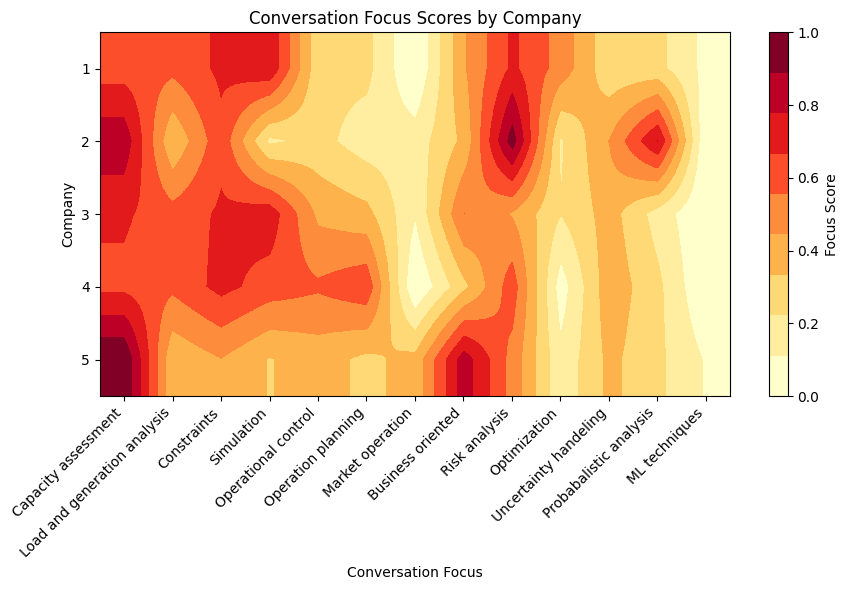

In [67]:
plt.figure(figsize=(len(focus_cols_sorted)*0.7, 6))
#plt.figure(figsize=(len(focus_cols_sorted)*0.7, 6))
im = plt.imshow(scores.values,  
               cmap=custom_cmap, 
               aspect='auto',
               interpolation='bilinear',  # Options: 'bilinear', 'bicubic', 'gaussian', 'lanczos'
               vmin=0, vmax=scores.max().max())

plt.colorbar(im, label='Focus Score')
plt.yticks(range(len(scores)), scores.index)  
plt.xticks(range(len(focus_col_names_sorted)), focus_col_names_sorted, rotation=45, ha='right')
plt.xlabel("Conversation Focus")
plt.ylabel("Company")
plt.title("Conversation Focus Scores by Company")
plt.tight_layout()
plt.show()

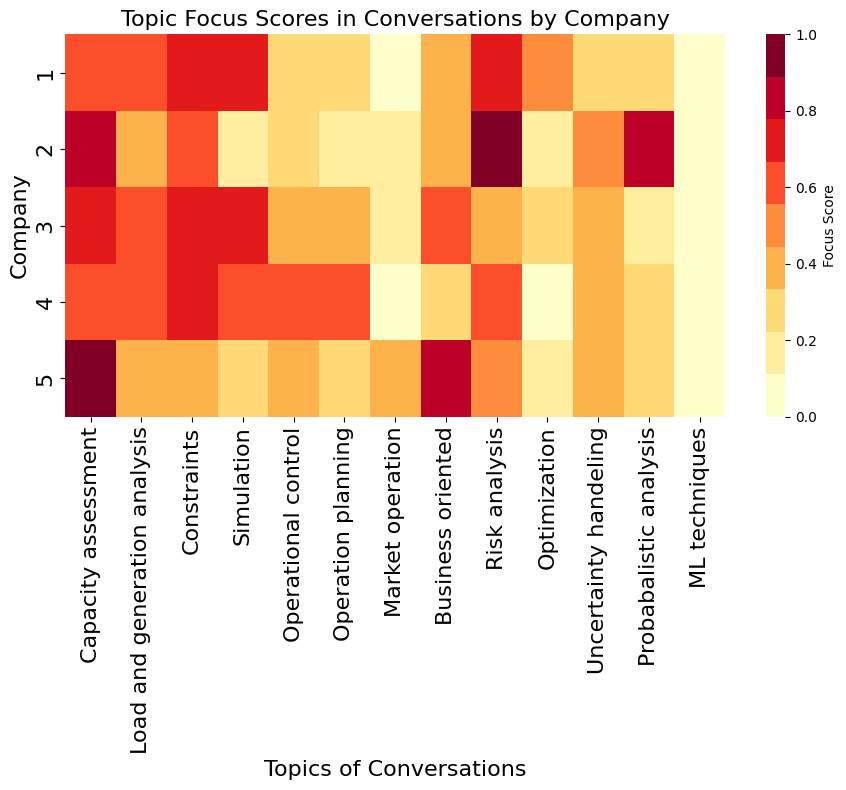

In [145]:
# Plot 1: By company Type
company_grouped = df_normalized.groupby('Respondent-Company')[focus_cols_sorted].mean()
scores_company = company_grouped / company_grouped.max().max()
fontsize=16
plt.figure(figsize=(len(focus_cols_sorted)*0.7, 8))
sns.heatmap(scores_company, 
           xticklabels=focus_col_names_sorted, 
           
           cmap=custom_cmap,
           vmin=0, vmax=scores_company.max().max(),
           annot=False,
           fmt='.2f',
           cbar_kws={'label': 'Focus Score'},
           )
plt.xlabel("Topics of Conversations",fontsize=fontsize)
plt.ylabel("Company",fontsize=fontsize)
plt.title("Topic Focus Scores in Conversations by Company",fontsize=fontsize)
plt.tick_params(axis='both', which='major', labelsize=fontsize)
plt.tight_layout()
plt.savefig("plots/focus_scores_by_company.pdf")
plt.show()




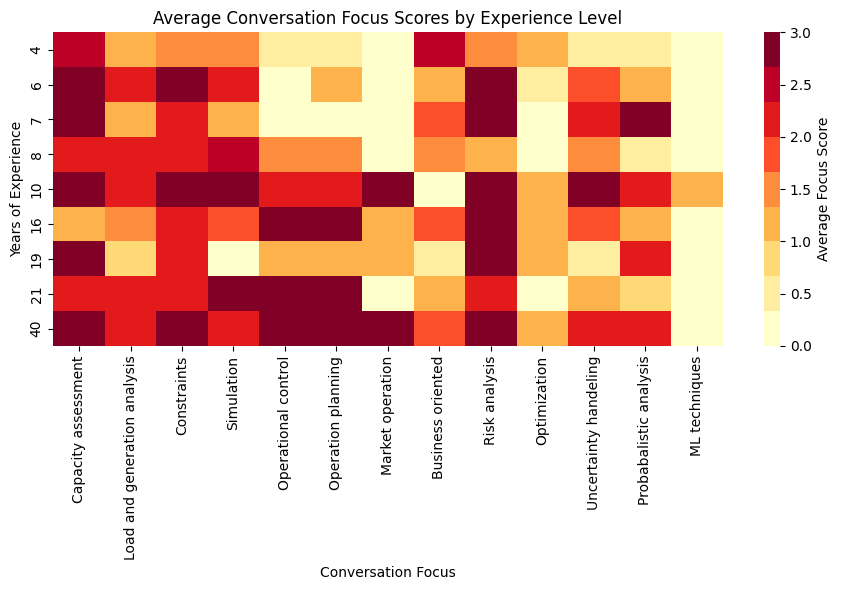

In [12]:
# Aggregated by Years of Experience
exp_grouped = df.groupby('Respondent-Years of relevant exp in total')[focus_cols_sorted].mean()
plt.figure(figsize=(len(focus_cols_sorted)*0.7, 6))
sns.heatmap(exp_grouped, 
           xticklabels=focus_col_names_sorted,
           cmap=custom_cmap,
           vmin=0, vmax=3,
           annot=False,
           fmt='.2f',
           cbar_kws={'label': 'Average Focus Score'})
plt.xlabel("Conversation Focus")
plt.ylabel("Years of Experience")
plt.title("Average Conversation Focus Scores by Experience Level")
plt.tight_layout()
plt.show()

C:\Users\STSI\AppData\Local\Temp\ipykernel_23112\2306700635.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  exp_grouped = df.groupby('Experience_Category')[focus_cols_sorted].mean()


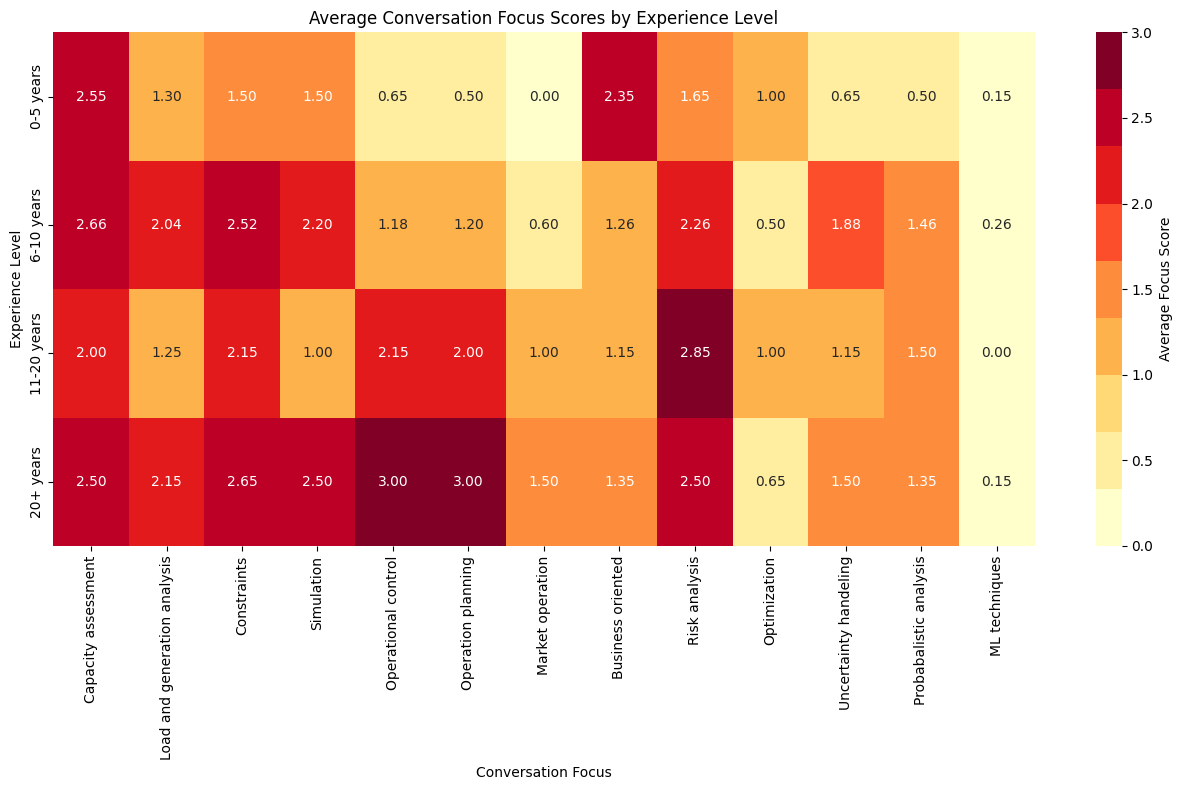

In [18]:
# Create experience bins
df['Experience_Category'] = pd.cut(
    pd.to_numeric(df['Respondent-Years of relevant exp in total'], errors='coerce'),
    bins=[0, 5, 10, 20, 50],
    labels=['0-5 years', '6-10 years', '11-20 years', '20+ years']
)

exp_grouped = df.groupby('Experience_Category')[focus_cols_sorted].mean()

plt.figure(figsize=(len(focus_cols_sorted)*1, 8))
sns.heatmap(exp_grouped, 
           xticklabels=focus_col_names_sorted,
           cmap=custom_cmap,
           vmin=0, vmax=3,
           annot=True,
           fmt='.2f',
           cbar_kws={'label': 'Average Focus Score'})
plt.xlabel("Conversation Focus")
plt.ylabel("Experience Level")
plt.title("Average Conversation Focus Scores by Experience Level")
plt.tight_layout()
plt.show()


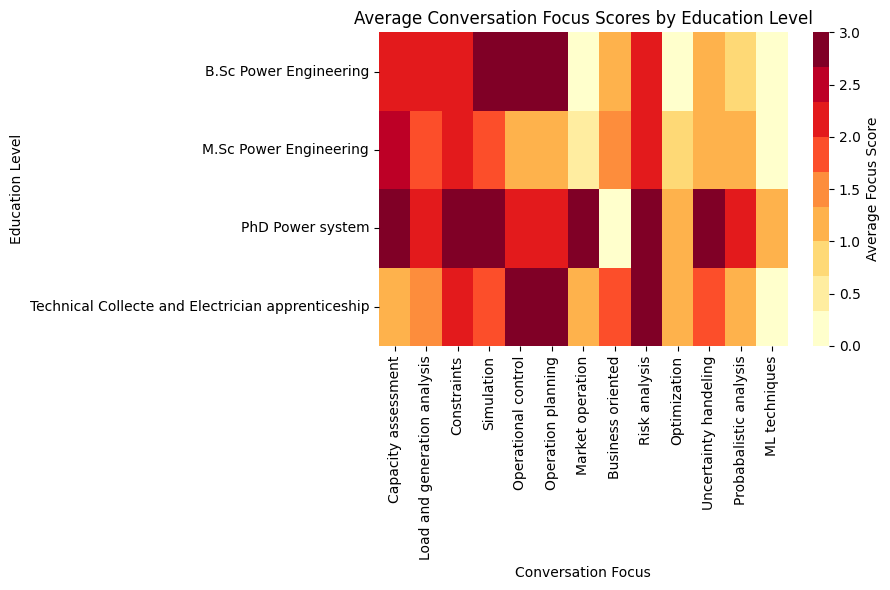

In [14]:
# Aggregated by Education Level
edu_grouped = df.groupby('Respondent-Education level')[focus_cols_sorted].mean()
plt.figure(figsize=(len(focus_cols_sorted)*0.7, 6))
sns.heatmap(edu_grouped, 
           xticklabels=focus_col_names_sorted,
           cmap=custom_cmap,
           vmin=0, vmax=3,
           #annot=True,
           fmt='.2f',
           cbar_kws={'label': 'Average Focus Score'})
plt.xlabel("Conversation Focus")
plt.ylabel("Education Level")
plt.title("Average Conversation Focus Scores by Education Level")
plt.tight_layout()
plt.show()

In [12]:
import plotly.express as px

# Create parallel coordinates plot
fig = px.parallel_coordinates(
    df,
    dimensions=focus_cols + ['Respondent-Education level', 'Respondent-Role'], 
    title="Multi-dimensional Focus Patterns")
fig.update_layout(
    xaxis=dict(
        tickmode='array',
        tickvals=list(range(len(focus_col_names))),
        ticktext=focus_col_names
    )
)
fig.show()


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
 [Text(0, 0, 'Capacity assessment'),
  Text(1, 0, 'Constraints '),
  Text(2, 0, 'Uncertainty handeling'),
  Text(3, 0, 'Probabalistic analysis'),
  Text(4, 0, 'Load and generation analysis'),
  Text(5, 0, 'Operational control'),
  Text(6, 0, 'Risk analysis'),
  Text(7, 0, 'Simulation'),
  Text(8, 0, 'Optimization'),
  Text(9, 0, 'ML techniques'),
  Text(10, 0, 'Business oriented'),
  Text(11, 0, 'Operation planning'),
  Text(12, 0, 'Market operation')])

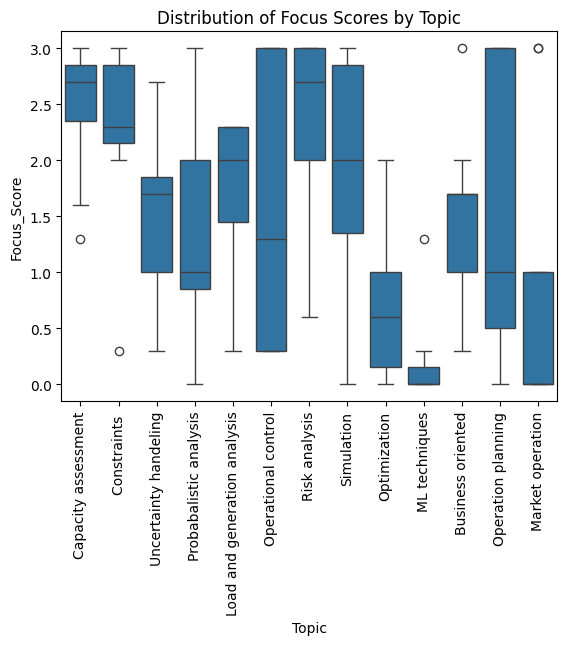

In [149]:
# Melt data for easier plotting
df_melted = df.melt(id_vars=['Respondent'], 
                   value_vars=focus_cols, 
                   var_name='Topic', 
                   value_name='Focus_Score')
df_melted['Topic'] = df_melted['Topic'].str.replace('Focus-', '')

# Create grouped visualization
plt.Figure(figsize=(12,8))
sns.boxplot(data=df_melted, x='Topic', y='Focus_Score')
plt.title('Distribution of Focus Scores by Topic')
plt.xticks(rotation=90)

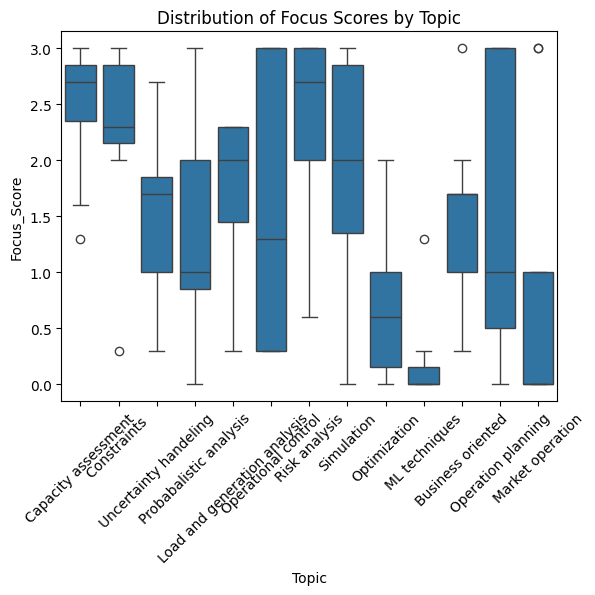

In [150]:
plt.Figure(figsize=(12,8))
sns.boxplot(data=df_melted, x='Topic', y='Focus_Score')
plt.title('Distribution of Focus Scores by Topic')
plt.xticks(rotation=45)
plt.show()

In [11]:
axes,fig,=plt.Figure(figsize=(12,8))
sns.boxplot(data=df_melted, x='Topic', y='Focus_Score', ax=axes[0])
axes.set_title('Distribution of Focus Scores by Topic')
axes.tick_params(axis='x', rotation=45)

TypeError: cannot unpack non-iterable Figure object

In [ ]:
for n in df.columns[:15]:print (n)

Respondent
Respondent-Role
Respondent-Years in current role
Respondent-Years of relevant exp in total
Respondent-Education level
Respondent-University
Focus-Capacity assessment
Focus-Constraints 
Focus-Uncertainty handeling
Focus-Probabalistic analysis
Focus-Load and generation analysis
Focus-Operational control
Focus-Risk analysis
Focus-Simulation
Focus-Optimization


C:\Users\STSI\AppData\Local\Temp\ipykernel_23112\4156739921.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  exp_focus = df.groupby('Experience-Level')[focus_cols].mean()


Text(0.5, 1.0, 'Average Focus by Experience Level')

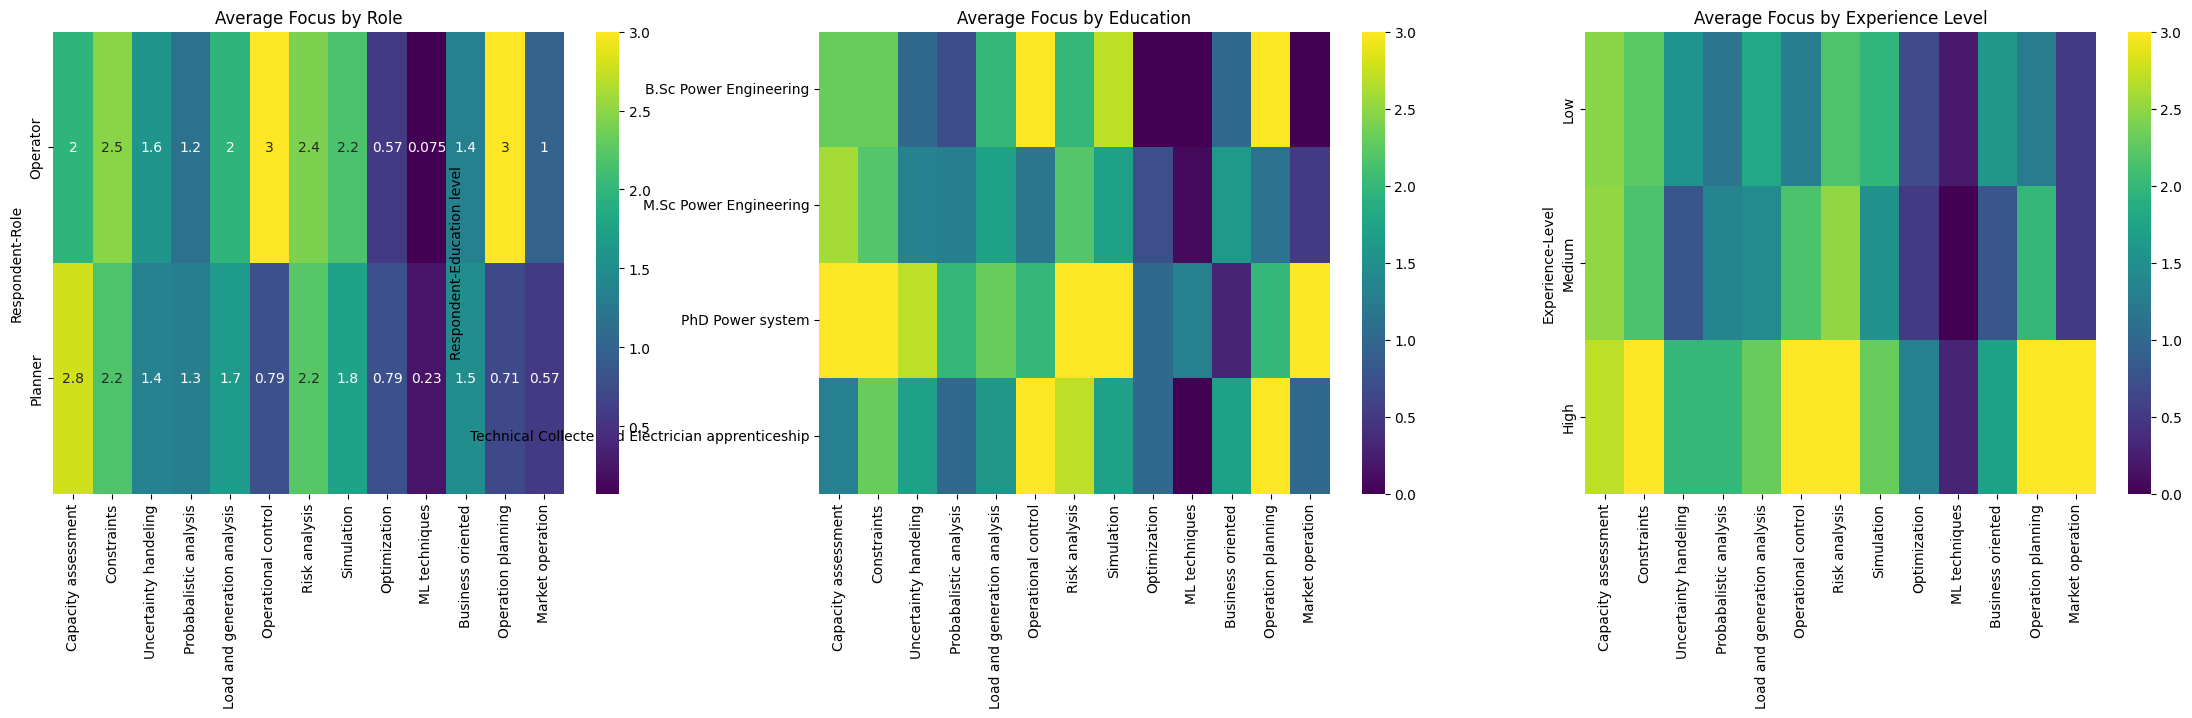

In [151]:
# Group by role/education and show average focus patterns
fig, axes = plt.subplots(1, 3, figsize=(28, 6))

# By role
role_focus = df.groupby('Respondent-Role')[focus_cols].mean()
sns.heatmap(role_focus, annot=True, ax=axes[0], 
           xticklabels=focus_col_names, cmap='viridis')
axes[0].set_title('Average Focus by Role')

# By education level
edu_focus = df.groupby('Respondent-Education level')[focus_cols].mean()
sns.heatmap(edu_focus, annot=False, ax=axes[1], 
           xticklabels=focus_col_names, cmap='viridis')
axes[1].set_title('Average Focus by Education')

# By experience level (create bins)
df['Experience-Level'] = pd.cut(df['Respondent-Years of relevant exp in total'], bins=3, labels=['Low', 'Medium', 'High'])
exp_focus = df.groupby('Experience-Level')[focus_cols].mean()
sns.heatmap(exp_focus, annot=False, ax=axes[2], 
           xticklabels=focus_col_names, cmap='viridis')
axes[2].set_title('Average Focus by Experience Level')


## Methods

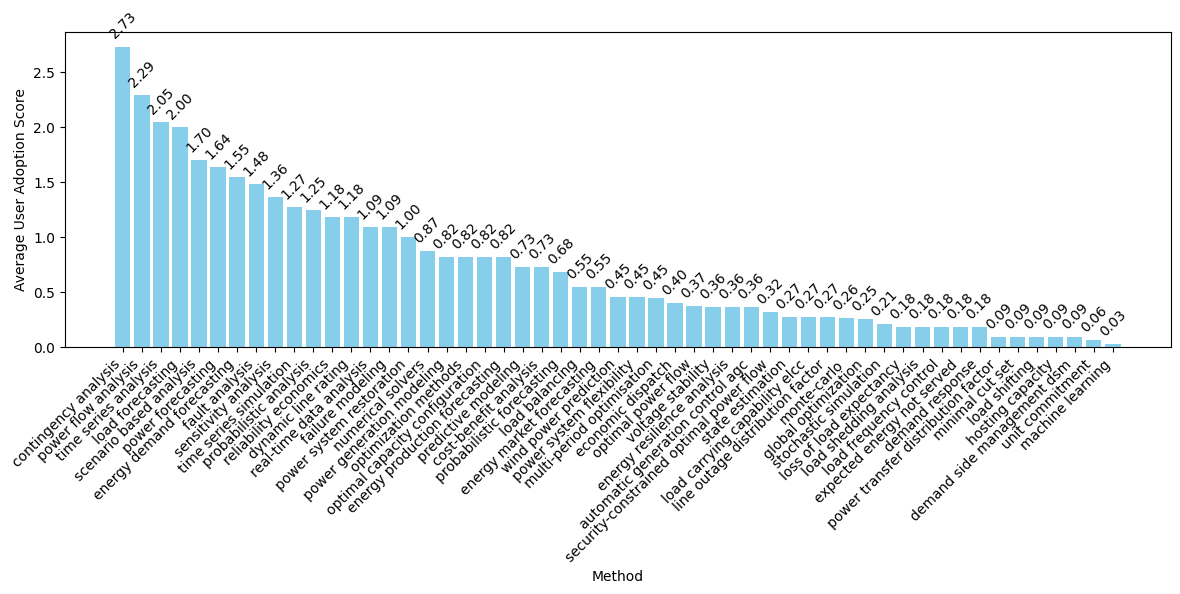

In [155]:
Method_cols = [col for col in df.columns if col.startswith("Method")]
# Calculate average prominence score for each method
method_scores = df[Method_cols].mean()
#filter out zero scores and keep only methods with scores above 0 incluing names
#filter out zero scores
method_scores = method_scores[method_scores > 0]
# crop the list to only methods with scores above 0
filtered_methods = [col for col in method_scores.index]
#strip "Methods-" from the name column (index) for method_scores
filtered_method_names = [col.replace("Methods-", "").strip() for col in method_scores.index]
#sort method_scores and filtered_method_names by method_scores descending
method_scores_tup, filtered_method_names_tup = zip(*sorted(zip(method_scores, filtered_method_names), reverse=True))

plt.figure(figsize=(12,6))


# plot only methods with scores above 0
bars = plt.bar(filtered_method_names_tup, method_scores_tup, color='skyblue')

plt.ylabel("Average User Adoption Score")
plt.xlabel("Method")
#plt.title('Average Importance/Prominence of Each Method')
#plt.ylim(0, 3)
plt.xticks(rotation=45, ha='right')

# Annotate bars with score values
for bar, score in zip(bars, method_scores_tup):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, f"{score:.2f}", ha='center', va='bottom',rotation=45)

plt.tight_layout()
plt.show()


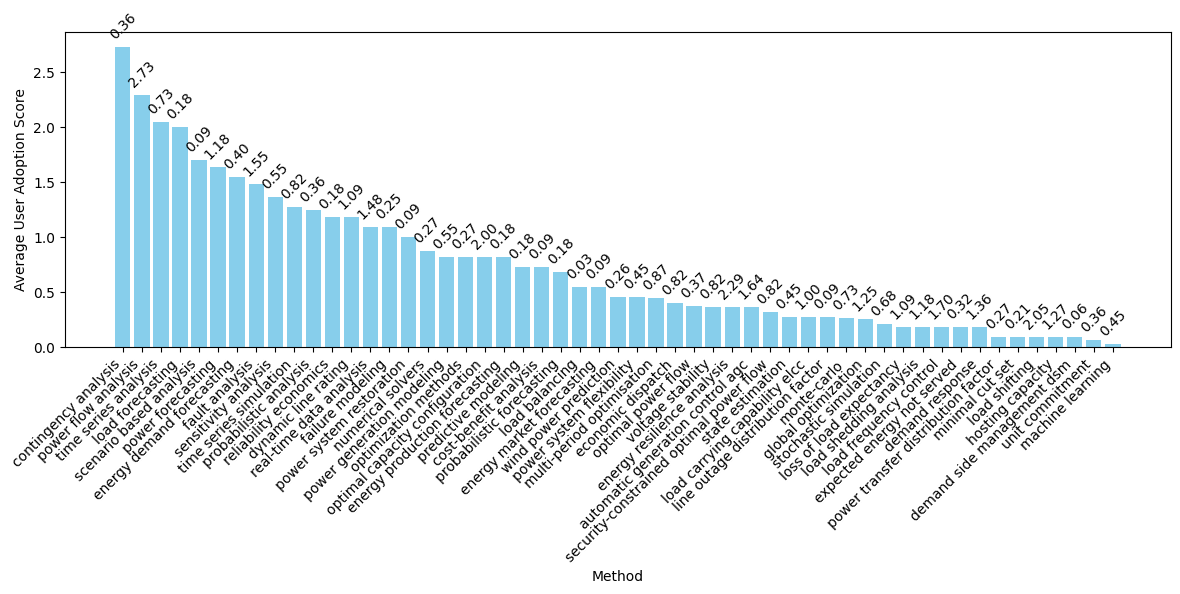

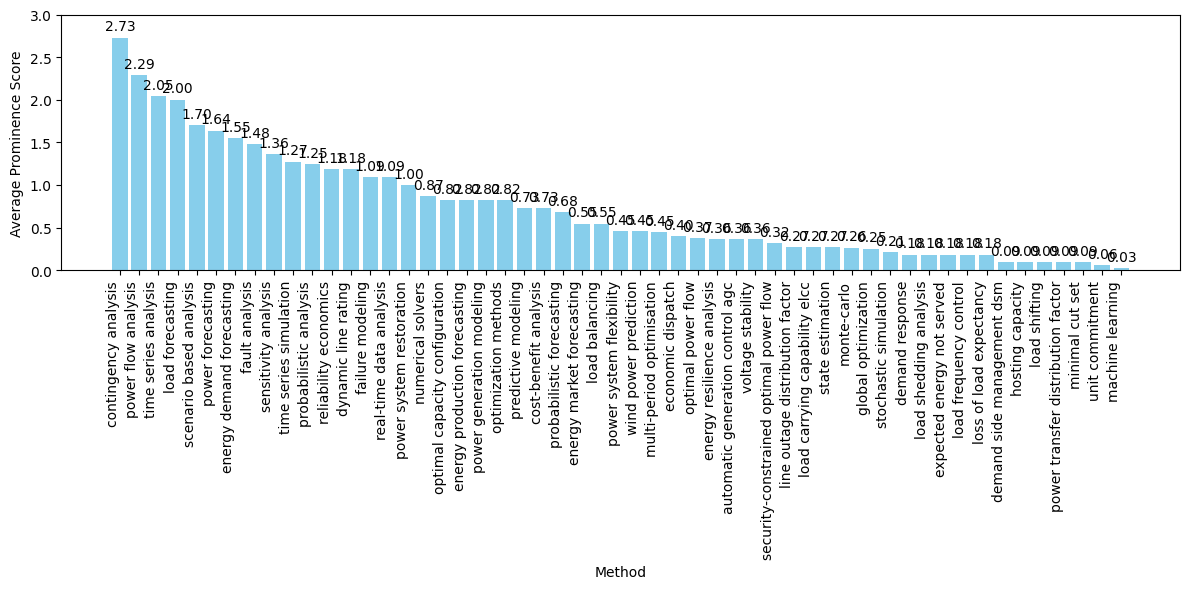

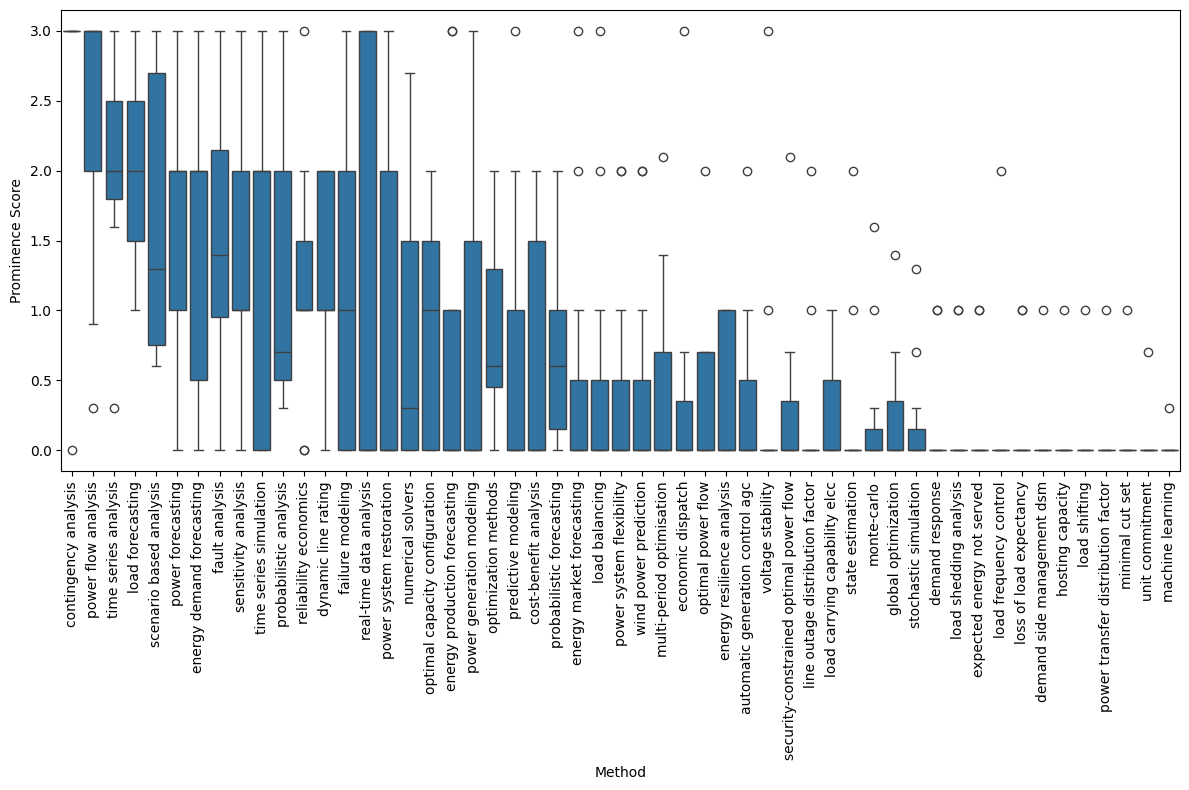

In [148]:
# Bar plot: Average prominence score per method, sorted descending
sorted_scores = method_scores.sort_values(ascending=False)
sorted_names = [col.replace("Methods-", "").strip() for col in sorted_scores.index]

plt.figure(figsize=(12,6))
bars = plt.bar(sorted_names, sorted_scores, color='skyblue')
plt.ylabel("Average Prominence Score")
plt.xlabel("Method")
plt.ylim(0, 3)
plt.xticks(rotation=90, ha='right')
for bar, score in zip(bars, sorted_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, f"{score:.2f}", ha='center', va='bottom')
plt.tight_layout()
plt.show()

# Box plot: Distribution of scores per method, sorted by average
df_methods_melted = df.melt(value_vars=Method_cols, var_name='Method', value_name='Score')
df_methods_melted['Method'] = df_methods_melted['Method'].str.replace('Methods-', '').str.strip()
df_methods_melted['Method'] = pd.Categorical(df_methods_melted['Method'], categories=sorted_names, ordered=True)

plt.figure(figsize=(12,8))
sns.boxplot(data=df_methods_melted, x='Method', y='Score')
plt.xticks(rotation=90)
plt.ylabel("Prominence Score")
plt.xlabel("Method")
plt.tight_layout()
plt.show()

## Softwares used

In [156]:
def count_software_usage(df):
    """Count software usage and map to readable names"""
    software_counts = {}
    
    # Get all software_type columns that exist in the dataframe
    software_type_cols = [col for col in df.columns if col.startswith("Software")]
    software_names = [col.replace("Software-", "").strip() for col in sorted_scores.index]
    for i,col in enumerate(software_type_cols):
        count = df[col].astype(int).sum().item()
        software_counts[software_names[i]] = count    
    return software_counts


In [157]:
def count_software_usage(df):
    """Count software usage and map to readable names"""
    software_counts = {}

    # Get all software_type columns that exist in the dataframe
    software_type_cols = [col for col in df.columns if col.startswith("Software")]
    software_names = [col.replace("Software-", "").strip() for col in software_type_cols]
    for col, name in zip(software_type_cols, software_names): # zip here is used to loop through one element from each of the lists (type and names) so that type1 and name1 will be the first pair, then type 2 and name 2 etc.
        count = df[col].astype(int).sum().item()
        software_counts[name] = count
    return software_counts

def convert_to_grouped_counts(software_counts):
    """Convert individual software counts to grouped structure"""
    
    # Define groups based on your actual software names
    SOFTWARE_GROUPS = {
        'SCADA Systems': ['SCADA'],
        'NIS (Network Information Systems)': ['Trimble NIS', 'Netbas NIS'],
        'Modelling & Programming Tools': [
            'Matlab & Simulink',
            'Python bibliotek (PyPSA, PandaPower og/eller PyPower) - RelyPES',
            'MatDyn',
            'MathPower'
        ],
        'Load Flow & Power Analysis': [
            'PSS/E, og/eller PSS Sincal',
            'PowerFactory',
            'NEPLAN',
            'Power World',
            'PSAT'
        ],
        'Business Intelligence & Analysis': [
            'Power BI',
            'DMS',
            'Aristo',
            'Eterra'
        ],
        'Maintenance & Operations': [
            'Revisjonsverktøy',
            'Fosweb'
        ],
        'Other/Specialized': [
            'Annen programvare (Spesifiser under påfølgende spørsmål)',
            'Internally developed',
            'None'
        ]
    }
    
    # Initialize group structures
    grouped_counts = {group: {} for group in SOFTWARE_GROUPS.keys()}
    group_totals = {group: 0 for group in SOFTWARE_GROUPS.keys()}
    
    # Map software to groups
    for software_name, count in software_counts.items():
        placed = False
        for group, members in SOFTWARE_GROUPS.items():
            if software_name in members:
                grouped_counts[group][software_name] = count
                group_totals[group] += count
                placed = True
                break
        
        # Handle unmatched software
        if not placed and count > 0:
            grouped_counts['Other/Specialized'][software_name] = count
            group_totals['Other/Specialized'] += count
            print(f"Added '{software_name}' to Other/Specialized")
    
    return grouped_counts, group_totals


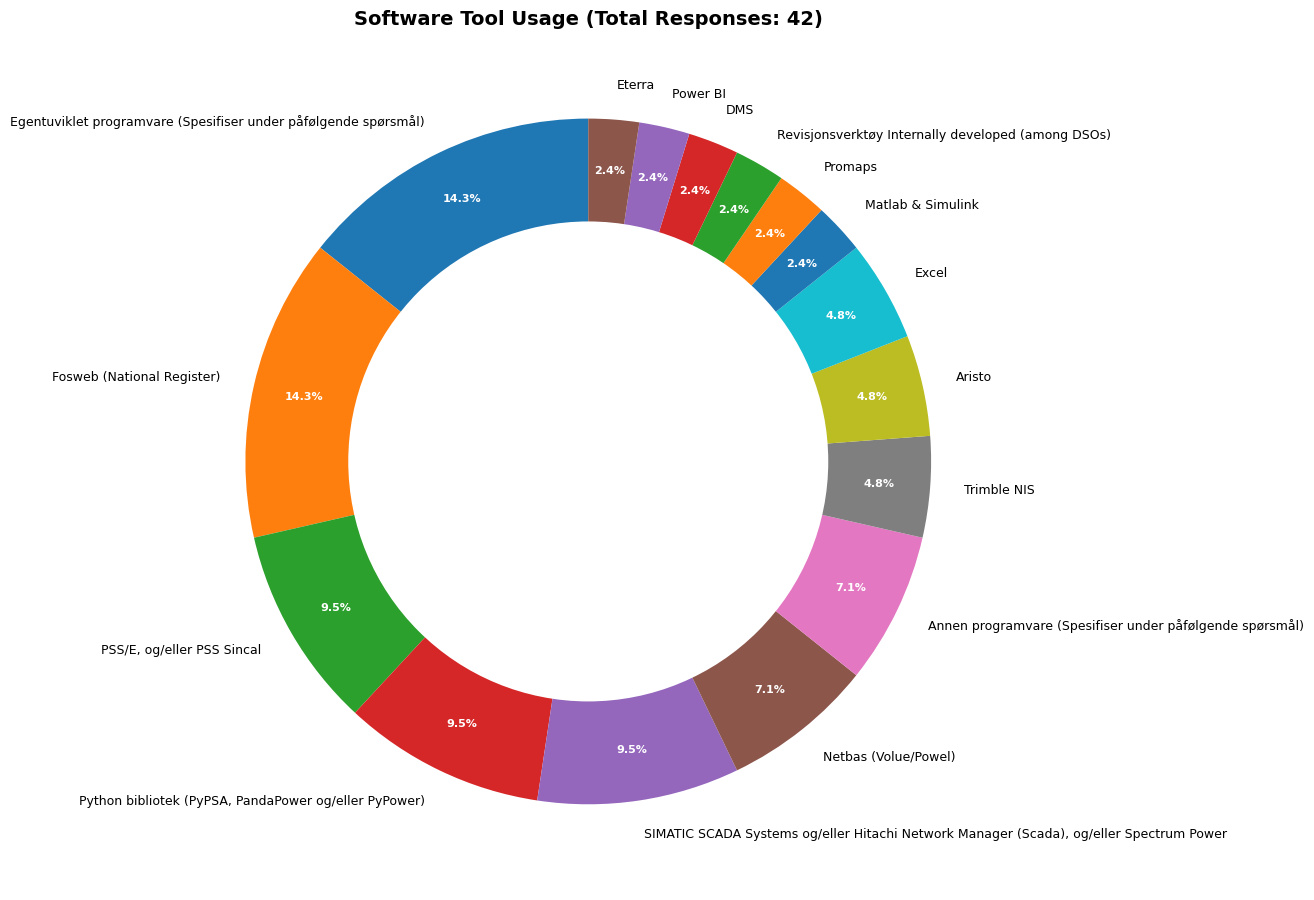

{'Matlab & Simulink': 1,
 'Netbas (Volue/Powel)': 3,
 'PSS/E, og/eller PSS Sincal': 4,
 'Python bibliotek (PyPSA, PandaPower og/eller PyPower)': 4,
 'SIMATIC SCADA Systems og/eller Hitachi Network Manager (Scada), og/eller Spectrum Power': 4,
 'Trimble NIS': 2,
 'Annen programvare (Spesifiser under påfølgende spørsmål)': 3,
 'Egentuviklet programvare (Spesifiser under påfølgende spørsmål)': 6,
 'Fosweb (National Register)': 6,
 'Promaps': 1,
 'Revisjonsverktøy Internally developed (among DSOs)': 1,
 'DMS': 1,
 'Power BI': 1,
 'Aristo': 2,
 'Eterra': 1,
 'Excel': 2}

In [158]:


def create_software_pie_chart(software_counts, min_count=1):
    """Create pie chart for software usage, filtering out unused software"""
    import matplotlib.pyplot as plt
    
    # Filter out software with zero or very low usage
    filtered_counts = {k: v for k, v in software_counts.items() if v >= min_count}
    
    if not filtered_counts:
        print("No software usage data to display")
        return
    
    # Sort by usage count (descending)
    sorted_items = sorted(filtered_counts.items(), key=lambda x: x[1], reverse=True)
    tools = [item[0] for item in sorted_items]
    cnts = [item[1] for item in sorted_items]
    
    total = sum(cnts)
    
    # Create pie chart
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Use autopct to show both percentage and count
    def autopct_format(pct):
        absolute = int(pct/100.*total)
        return f'{pct:.1f}%'#\n({absolute})'
    
    wedges, texts, autotexts = ax.pie(cnts, labels=tools, autopct=autopct_format, 
                                      startangle=90, pctdistance=0.85)
    
    # Improve text readability
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(8)
    
    for text in texts:
        text.set_fontsize(9)
    
    ax.set_title(f'Software Tool Usage (Total Responses: {total})', fontsize=14, fontweight='bold')
    
    # Add center circle for donut chart effect
    centre_circle = plt.Circle((0,0), 0.70, fc='white')
    fig.gca().add_artist(centre_circle)
    
    plt.tight_layout()
    plt.show()
    
    return filtered_counts

#Plot the counts
software_counts=count_software_usage(df)
create_software_pie_chart(software_counts)
#for s in list(software_counts):print(f"Software:{s}")

In [ ]:
def create_grouped_software_pie_chart(grouped_counts, group_totals, min_count=1):
    """Create pie chart showing software groups with totals"""
    import matplotlib.pyplot as plt
    import numpy as np
    
    # Filter out groups with zero or very low usage
    filtered_totals = {k: v for k, v in group_totals.items() if v >= min_count}
    
    if not filtered_totals:
        print("No software usage data to display")
        return
    
    # Sort by usage count (descending)
    sorted_items = sorted(filtered_totals.items(), key=lambda x: x[1], reverse=True)
    group_names = [item[0] for item in sorted_items]
    group_counts = [item[1] for item in sorted_items]
    
    total = sum(group_counts)
    
    # Create pie chart
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Define colors for groups
    colors = plt.cm.Set3(np.linspace(0, 1, len(group_names)))
    
    # Use autopct to show percentage and count
    def autopct_format(pct):
        absolute = int(pct/100.*total)
        return f'{pct:.1f}%\n({absolute})'
    
    wedges, texts, autotexts = ax.pie(group_counts, labels=group_names, autopct=autopct_format,
                                      startangle=90, pctdistance=0.85, colors=colors)
    
    # Improve text readability
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(10)
    
    for text in texts:
        text.set_fontsize(11)
        text.set_fontweight('bold')
    
    ax.set_title(f'Software Usage by Functional Group (Total Responses: {total})', 
                fontsize=14, fontweight='bold')
    
    # Add center circle for donut chart effect
    centre_circle = plt.Circle((0,0), 0.70, fc='white')
    fig.gca().add_artist(centre_circle)
    
    plt.tight_layout()
    plt.show()
    
    return filtered_totals



Added 'Netbas (Volue/Powel)' to Other/Specialized
Added 'Python bibliotek (PyPSA, PandaPower og/eller PyPower)' to Other/Specialized
Added 'SIMATIC SCADA Systems og/eller Hitachi Network Manager (Scada), og/eller Spectrum Power' to Other/Specialized
Added 'Egentuviklet programvare (Spesifiser under påfølgende spørsmål)' to Other/Specialized
Added 'Fosweb (National Register)' to Other/Specialized
Added 'Promaps' to Other/Specialized
Added 'Revisjonsverktøy Internally developed (among DSOs)' to Other/Specialized
Added 'Excel' to Other/Specialized
Group Totals:
NIS (Network Information Systems): 2
Modelling & Programming Tools: 1
Load Flow & Power Analysis: 4
Business Intelligence & Analysis: 5
Other/Specialized: 30

Detailed Breakdown:

NIS (Network Information Systems) (Total: 2):
  • Trimble NIS: 2

Modelling & Programming Tools (Total: 1):
  • Matlab & Simulink: 1

Load Flow & Power Analysis (Total: 4):
  • PSS/E, og/eller PSS Sincal: 4

Business Intelligence & Analysis (Total: 5):
  

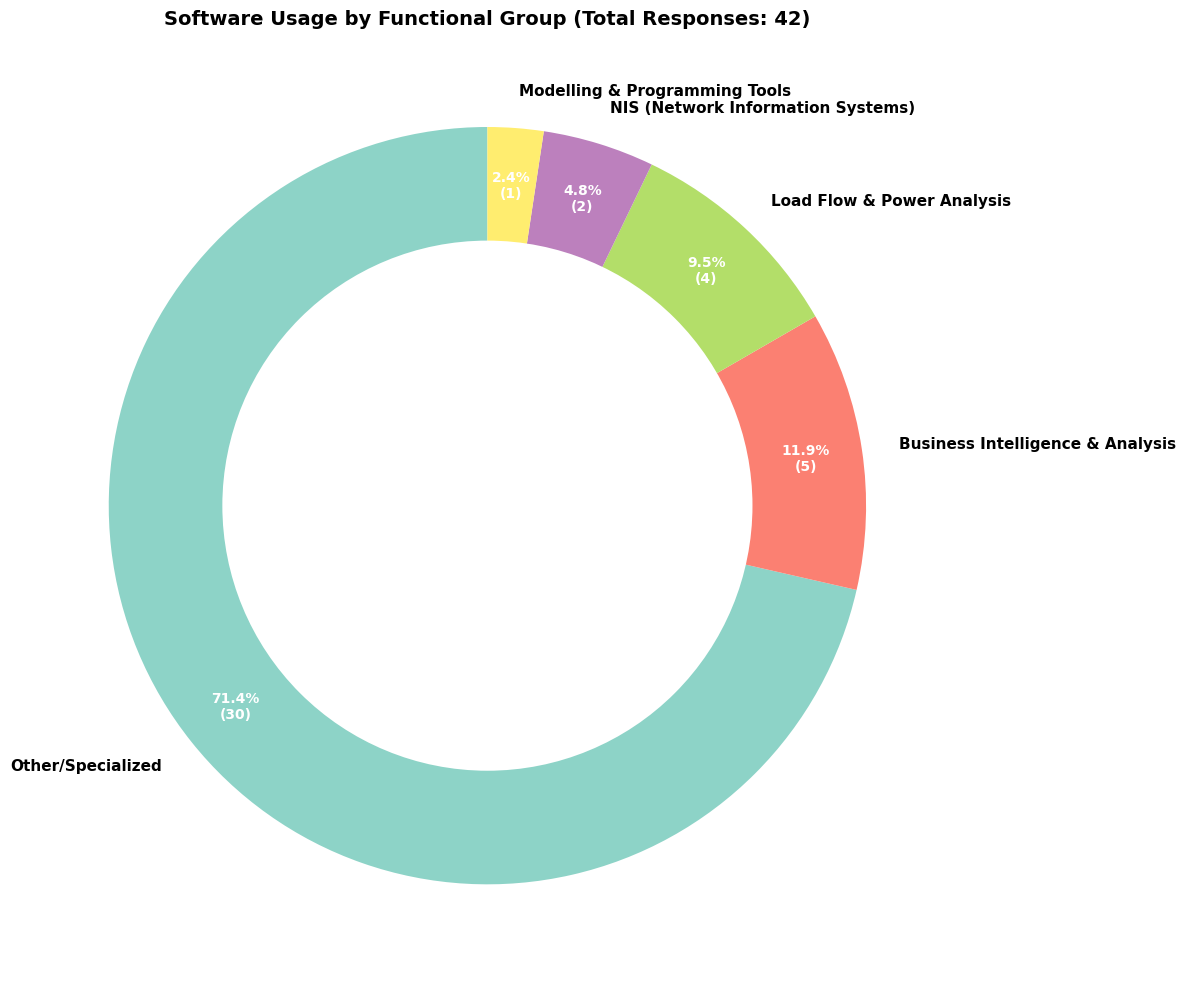

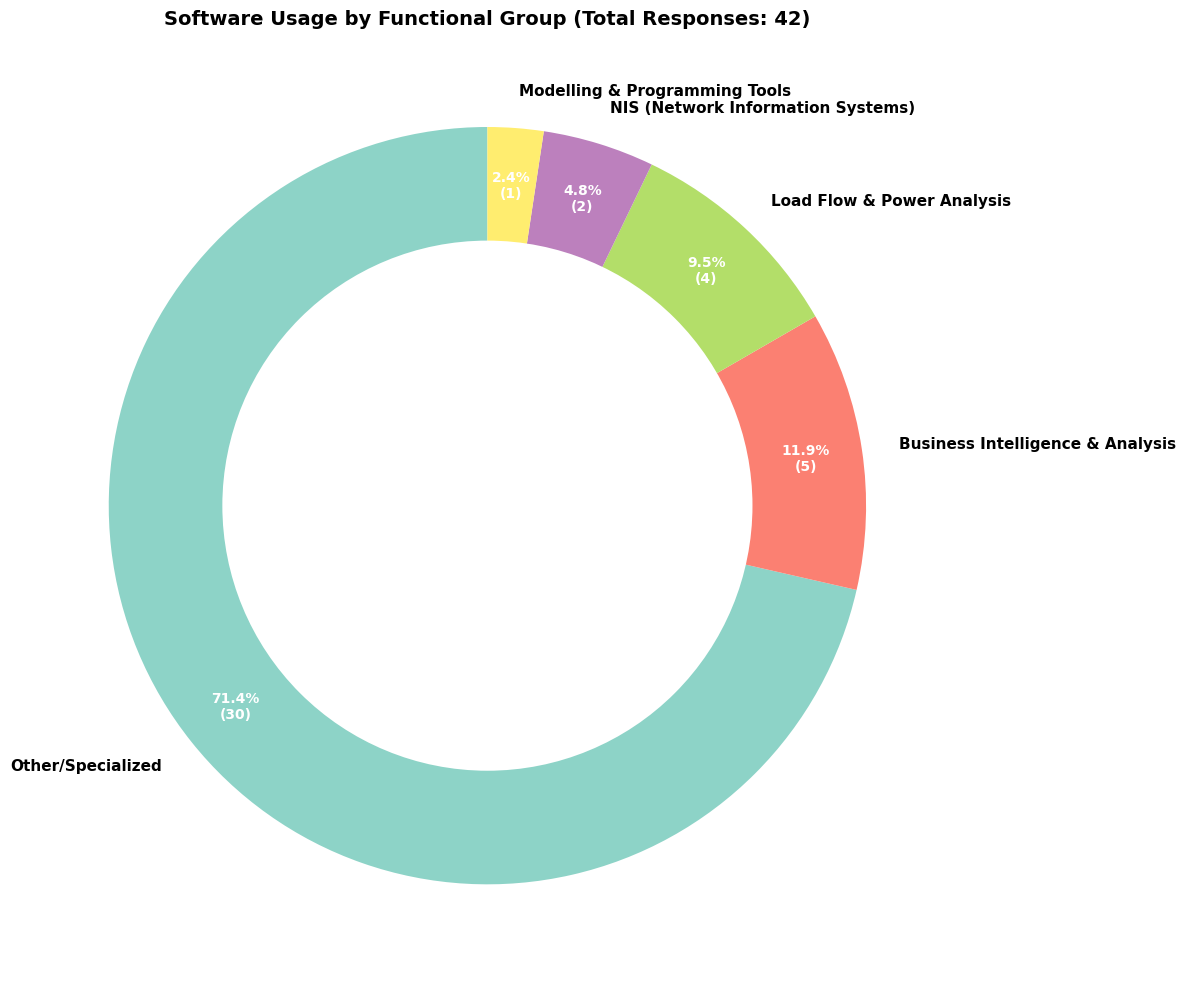

In [ ]:
# Method 2: Convert existing counts
software_counts = count_software_usage(df)  # Your existing function
grouped_counts, group_totals = convert_to_grouped_counts(software_counts)

# Print results
print("Group Totals:")
for group, total in group_totals.items():
    if total > 0:
        print(f"{group}: {total}")

print("\nDetailed Breakdown:")
for group, software_dict in grouped_counts.items():
    if group_totals[group] > 0:
        print(f"\n{group} (Total: {group_totals[group]}):")
        for software, count in software_dict.items():
            if count > 0:
                print(f"  • {software}: {count}")

# Create pie chart
create_grouped_software_pie_chart(grouped_counts, group_totals)

# Usage:
grouped_counts = count_software_usage(df)
grouped_results = create_grouped_software_pie_chart(grouped_counts, group_totals)


## Barriers

In [ ]:
# 1. Get barrier columns and create labels by stripping prefix
import numpy as np
barrier_cols = [col for col in df.columns 
                if col.startswith("Barriers-") 
                and not col.lower().endswith('desc')]

barrier_labels = [col.replace("Barriers-", "") for col in barrier_cols]

print(f"Found {len(barrier_cols)} interview barrier columns")

# 2. Calculate percentages for each barrier (0-5 scale)
barrier_stats = []
for col in barrier_cols:
    # count values in the intervalls 0-0.5(as 0), 0.5-1.5(as 1), 1.5 - 2-5(as 2), 2.5-3.5(as 3)`, 3.5-4 (as 4) and 4-5 (as 5)
    counts = df[col].value_counts(bins=[0,0.5,1.5,2.5,3.5,4.5,5.0], sort=False)
    total = counts.sum()
    percentages = (counts / total * 100).reindex(pd.IntervalIndex.from_tuples([(0,0.5),(0.5,1.5),(1.5,2.5),(2.5,3.5),(3.5,4.5),(4.5,5.0)])).fillna(0)
    barrier_stats.append(percentages.values)
barrier_stats = np.array(barrier_stats)  # shape: (num_barriers, 6)

# Create sorted indices
indices = [i for i in range(len(barrier_labels)) if i != other_idx]
sorted_indices = sorted(indices, key=lambda i: severity_scores[i], reverse=True)

# Add "Other" barriers at the beginning (will be at bottom of plot)
if other_idx is not None:
    sorted_indices.insert(0, other_idx)

# Reorder all data
ordered_labels = [barrier_labels[i] for i in sorted_indices]
ordered_arrays = [not_relevant, not_barrier, small, moderate, critical]
ordered_arrays = [np.array([arr[i] for i in sorted_indices]) for arr in ordered_arrays]

ordered_not_relevant, ordered_not_barrier, ordered_small, ordered_moderate, ordered_critical = ordered_arrays



Found 8 interview barrier columns


In [ ]:
counts = df['Barriers-Results Difficult to Interpret'].value_counts(bins=[0,0.5,1.5,2.5,3.5,4.5,5.0], sort=False)
total = counts.sum()
#percentages = (counts / total * 100).reindex(pd.IntervalIndex.from_tuples([(0,0.5),(0.5,1.5),(1.5,2.5),(2.5,3.5),(3.5,4.5),(4.5,5.0)],closed='right')).fillna(0)
percentages = (counts / total * 100)

In [ ]:
print(counts)
print(percentages)

(-0.001, 0.5]    3
(0.5, 1.5]       3
(1.5, 2.5]       3
(2.5, 3.5]       2
(3.5, 4.5]       0
(4.5, 5.0]       0
Name: count, dtype: int64
(-0.001, 0.5]    27.272727
(0.5, 1.5]       27.272727
(1.5, 2.5]       27.272727
(2.5, 3.5]       18.181818
(3.5, 4.5]        0.000000
(4.5, 5.0]        0.000000
Name: count, dtype: float64


In [ ]:
def create_interview_barrier_plot(df):
    """Create barrier severity plot for interview data - strips 'Barriers-' prefix for labels"""
    import numpy as np
    import matplotlib.pyplot as plt
    
    # 1. Get barrier columns and create labels by stripping prefix
    barrier_cols = [col for col in df.columns 
                   if col.startswith("Barriers-") 
                   and not col.lower().endswith('desc')]
    
    barrier_labels = [col.replace("Barriers-", "") for col in barrier_cols]
    
    print(f"Found {len(barrier_cols)} interview barrier columns")
    
    # 2. Calculate percentages for each barrier (0-5 scale)
    barrier_stats = []
    for col in barrier_cols:
        counts = df[col].value_counts(bins=[0,0.5,1.5,2.5,3.5,4.5,5.0], sort=False)
        total = counts.sum()
        percentages = (counts / total * 100)
        barrier_stats.append(percentages.values)
    barrier_stats = np.array(barrier_stats)  # shape: (num_barriers, 6)

    
    # 3. Extract severity arrays
    not_relevant = np.array([stats[0] for stats in barrier_stats])    # Rating 0
    not_barrier = np.array([stats[1] for stats in barrier_stats])     # Rating 1
    small = np.array([stats[2] for stats in barrier_stats])           # Rating 2
    moderate = np.array([stats[3] for stats in barrier_stats])        # Rating 3
    critical = np.array([stats[4] + stats[5] for stats in barrier_stats])  # Ratings 4+5
    
    # 4. Reorder barriers: most severe at top, "Other" barriers at bottom
    severity_scores = critical + moderate * 0.5 + small * 0.2
    
    # Find "Other" barriers index
    other_idx = None
    for i, label in enumerate(barrier_labels):
        if 'other' in label.lower():
            other_idx = i
            break
    
    # Create sorted indices
    indices = [i for i in range(len(barrier_labels)) if i != other_idx]
    sorted_indices = sorted(indices, key=lambda i: severity_scores[i], reverse=True)
    
    # Add "Other" barriers at the beginning (will be at bottom of plot)
    if other_idx is not None:
        sorted_indices.insert(0, other_idx)
    
    # Reorder all data
    ordered_labels = [barrier_labels[i] for i in sorted_indices]
    ordered_arrays = [not_relevant, not_barrier, small, moderate, critical]
    ordered_arrays = [np.array([arr[i] for i in sorted_indices]) for arr in ordered_arrays]
    
    ordered_not_relevant, ordered_not_barrier, ordered_small, ordered_moderate, ordered_critical = ordered_arrays
    
    # 5. Create the plot (same style as questionnaire)
    fig, ax = plt.subplots(figsize=(14, 8))
    y_pos = np.arange(len(ordered_labels))
    
    # Plot diverging bars
    ax.barh(y_pos, -ordered_not_relevant, left=-ordered_not_barrier, 
            color='lightblue', label='Not relevant/No opinion (0)')
    ax.barh(y_pos, -ordered_not_barrier, color='lightgreen', label='Not a barrier (1)')
    ax.barh(y_pos, ordered_small, left=0, color='lightgray', label='Small (2)')
    ax.barh(y_pos, ordered_moderate, left=ordered_small, color='yellow', label='Moderate (3)')
    ax.barh(y_pos, ordered_critical, left=ordered_small + ordered_moderate, 
            color='red', label='Critical barrier (4-5)')
    
    # 6. Add percentage labels
    for i in range(len(ordered_labels)):
        if ordered_critical[i] > 5:
            ax.text(ordered_small[i] + ordered_moderate[i] + ordered_critical[i]/2, i, 
                   f'{ordered_critical[i]:.0f}%', ha='center', va='center', 
                   color='white', fontweight='bold')
        if ordered_not_barrier[i] > 5:
            ax.text(-ordered_not_barrier[i]/2, i, f'{ordered_not_barrier[i]:.0f}%', 
                   ha='center', va='center', color='black', fontweight='bold')
        if ordered_not_relevant[i] > 5:
            ax.text(-ordered_not_barrier[i] - ordered_not_relevant[i]/2, i, 
                   f'{ordered_not_relevant[i]:.0f}%', ha='center', va='center', 
                   color='black', fontweight='bold')
        if ordered_moderate[i] > 8:
            ax.text(ordered_small[i] + ordered_moderate[i]/2, i, f'{ordered_moderate[i]:.0f}%', 
                   ha='center', va='center', color='black', fontweight='bold')
        if ordered_small[i] > 8:
            ax.text(ordered_small[i]/2, i, f'{ordered_small[i]:.0f}%', 
                   ha='center', va='center', color='black', fontweight='bold')
    
    # 7. Format axes
    ax.set_yticks(y_pos)
    ax.set_yticklabels(ordered_labels)
    ax.set_xlabel('Percentage of Respondents')
    ax.set_title('Interview: Barrier Severity Distribution', fontsize=14, fontweight='bold')
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
    ax.axvline(x=0, color='black', linewidth=0.5)
    
    plt.tight_layout()
    plt.show()
    
    return fig


Found 8 interview barrier columns


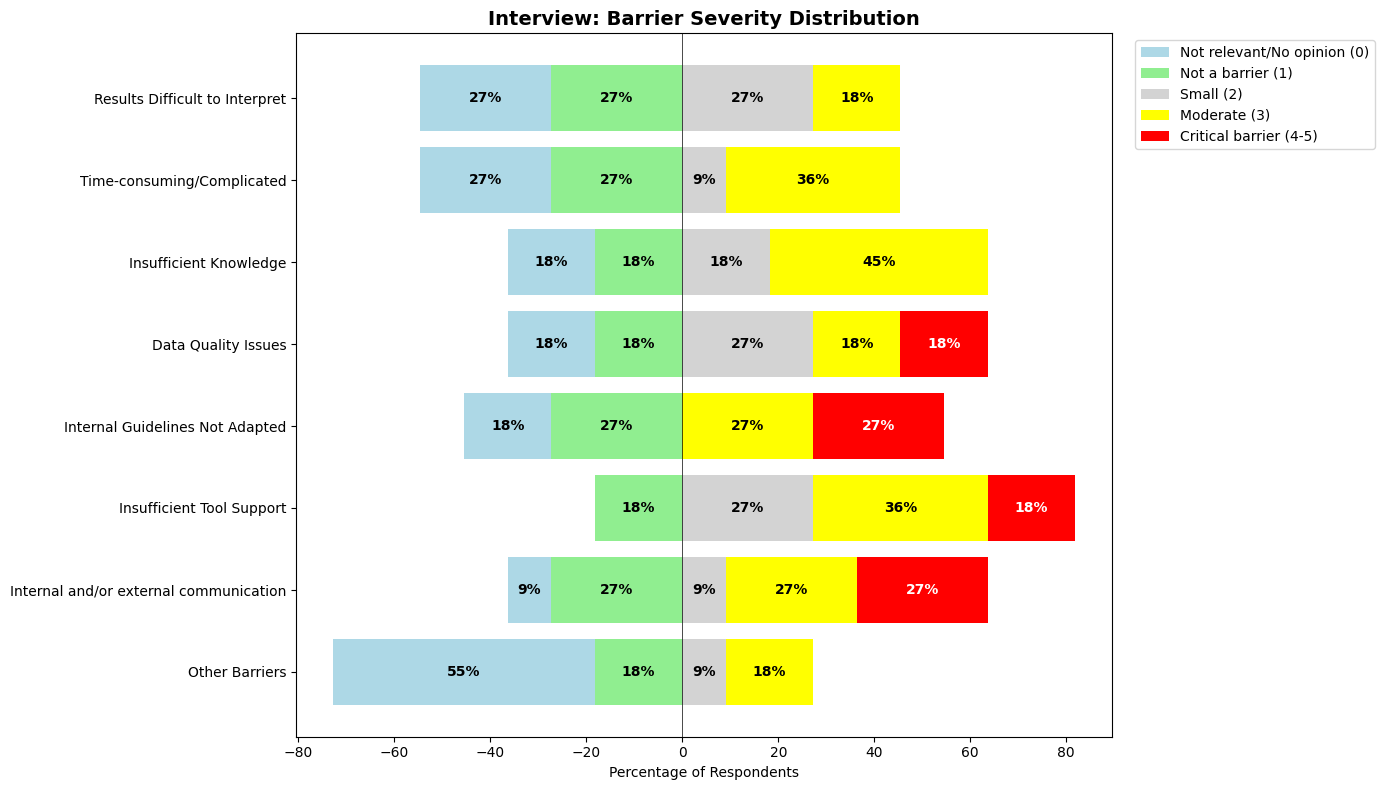

Interview barrier columns found:
  Barriers-Results Difficult to Interpret → Results Difficult to Interpret
  Barriers-Data Quality Issues → Data Quality Issues
  Barriers-Internal Guidelines Not Adapted → Internal Guidelines Not Adapted
  Barriers-Time-consuming/Complicated → Time-consuming/Complicated
  Barriers-Insufficient Tool Support → Insufficient Tool Support
  Barriers-Insufficient Knowledge → Insufficient Knowledge
  Barriers-Internal and/or external communication → Internal and/or external communication
  Barriers-Other Barriers → Other Barriers


In [ ]:
# Simply call with your interview dataframe
interview_fig = create_interview_barrier_plot(df)

# Print column info to verify
barrier_cols = [col for col in df.columns if col.startswith("Barriers-")]
print("Interview barrier columns found:")
for col in barrier_cols:
    label = col.replace("Barriers-", "")
    print(f"  {col} → {label}")
